# ARIMA Forecasting — Portfolio & Individual Stock Analysis

> **Goal:** Demonstrate the power of ARIMA for financial time-series forecasting.
> We build **three distinct models** — two individual stocks and one equal-weighted portfolio — then compare their forecasts on a polished dashboard.

---

## 0 — Setup & Global Style

In [2]:
import warnings, itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Global plot style ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "#FAFAFA",
    "axes.facecolor":     "#FAFAFA",
    "axes.edgecolor":     "#CCCCCC",
    "axes.grid":          True,
    "grid.color":         "#E5E5E5",
    "grid.linewidth":     0.6,
    "font.family":        "sans-serif",
    "font.size":          11,
    "axes.titlesize":     15,
    "axes.titleweight":   "bold",
    "axes.labelsize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#CCCCCC",
    "figure.dpi":         130,
})

PALETTE = {
    "train":    "#3B82F6",
    "test":     "#10B981",
    "forecast": "#EF4444",
    "ci":       "#FCA5A5",
    "accent1":  "#8B5CF6",
    "accent2":  "#F59E0B",
    "accent3":  "#06B6D4",
    "grid":     "#E5E5E5",
}

print("Libraries loaded ✓")

Libraries loaded ✓


## 1 — Fetch Data from Yahoo Finance

We pull **daily closing prices** for our 10-stock universe (Jan 2020 → today) and build an **equal-weighted portfolio** index.

In [3]:
TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL",
           "TSLA", "META", "JPM",  "V",    "UNH"]

raw = yf.download(TICKERS, start="2020-01-01", end="2026-01-01",
                  group_by="ticker", auto_adjust=True)

# Flatten multi-index → keep Close prices only
close_cols = [(t, "Close") for t in TICKERS]
df_prices = raw[[c for c in close_cols if c in raw.columns]].copy()
df_prices.columns = [c[0] for c in df_prices.columns]
df_prices.dropna(inplace=True)

# Equal-weighted portfolio (normalized to $100 at inception)
df_returns = df_prices.pct_change().dropna()
portfolio_returns = df_returns.mean(axis=1)
df_prices["PORTFOLIO"] = 100 * (1 + portfolio_returns).cumprod()

print(f"Date range : {df_prices.index[0].date()} → {df_prices.index[-1].date()}")
print(f"Trading days: {len(df_prices):,}")
df_prices.tail(3)

[*********************100%***********************]  10 of 10 completed

Date range : 2020-01-02 → 2025-12-31
Trading days: 1,508


,AAPL,MSFT,NVDA,AMZN,GOOGL,TSLA,META,JPM,V,UNH,PORTFOLIO
Date,,,,,,,,,,,
2025-12-29,273.504089,485.990753,188.209808,232.070007,313.339417,459.640015,658.126526,320.655182,353.880249,326.402435,533.453409
2025-12-30,272.824707,486.369904,187.529846,232.529999,313.629242,454.429993,665.380310,320.328369,352.892303,329.597626,533.627074
2025-12-31,271.605835,482.518677,186.489914,230.820007,312.779816,449.720001,659.525330,319.139801,349.988281,327.563416,530.144138


### Portfolio Overview — Normalized Price Paths

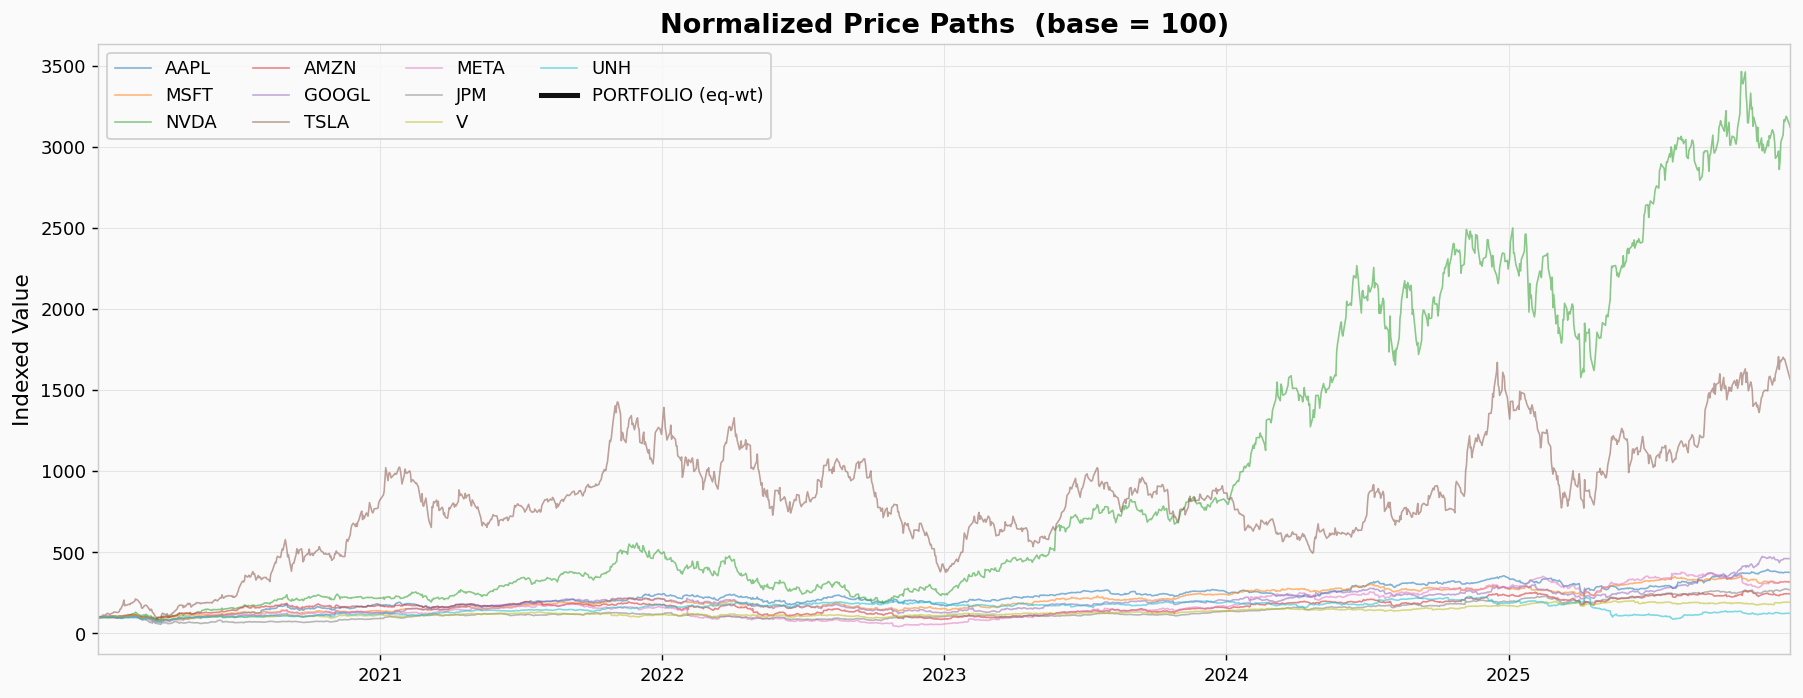

In [4]:
# Normalize every stock to 100 at start for visual comparison
norm = df_prices.div(df_prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 5.5))
cmap = plt.cm.tab10
for i, col in enumerate(TICKERS):
    ax.plot(norm.index, norm[col], linewidth=0.9, alpha=0.55, color=cmap(i), label=col)

ax.plot(norm.index, norm["PORTFOLIO"], linewidth=2.8, color="#111111",
        label="PORTFOLIO (eq-wt)", zorder=5)

ax.set_title("Normalized Price Paths  (base = 100)")
ax.set_ylabel("Indexed Value")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(ncol=4, loc="upper left", frameon=True)
ax.set_xlim(norm.index[0], norm.index[-1])
fig.tight_layout()
plt.show()

---

## 2 — Helper: Best-Order ARIMA via Grid Search + Forecast Plotter

We test a range of `(p, d, q)` combos and pick the one with the **lowest AIC**. A reusable plotting function keeps every chart consistent.

In [5]:
TRAIN_FRAC = 0.85          # 85 % train / 15 % test
FORECAST_DAYS = 60         # extra days beyond the test set

def find_best_arima(series, max_p=3, max_d=2, max_q=3):
    """Grid-search (p,d,q) by AIC on the training portion."""
    best_aic, best_order = np.inf, (1, 1, 1)
    for p, d, q in itertools.product(range(max_p + 1),
                                      range(max_d + 1),
                                      range(max_q + 1)):
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(series, order=(p, d, q))
            res = model.fit()
            if res.aic < best_aic:
                best_aic, best_order = res.aic, (p, d, q)
        except Exception:
            continue
    return best_order, best_aic


def run_arima_pipeline(series, label, color_main=PALETTE["train"]):
    """
    End-to-end: split → fit best ARIMA → forecast → return artefacts dict.
    """
    split = int(len(series) * TRAIN_FRAC)
    train, test = series.iloc[:split], series.iloc[split:]

    order, aic = find_best_arima(train)
    print(f"  Best order for {label}: ARIMA{order}  (AIC = {aic:,.0f})")

    model = ARIMA(train, order=order).fit()

    n_forecast = len(test) + FORECAST_DAYS
    fc = model.get_forecast(steps=n_forecast)
    fc_mean = fc.predicted_mean
    fc_ci   = fc.conf_int(alpha=0.05)

    future_idx = pd.bdate_range(start=train.index[-1] + pd.Timedelta(days=1),
                                periods=n_forecast)
    fc_mean.index = future_idx
    fc_ci.index   = future_idx

    return dict(train=train, test=test, order=order, aic=aic,
                model=model, fc_mean=fc_mean, fc_ci=fc_ci, label=label)


def plot_arima_forecast(res, figsize=(14, 5.5)):
    """
    Publication-quality forecast chart with train / test / forecast + 95 % CI.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Train
    ax.plot(res["train"].index, res["train"], color=PALETTE["train"],
            linewidth=1.0, label="Training data")

    # Test (actual)
    ax.plot(res["test"].index, res["test"], color=PALETTE["test"],
            linewidth=1.3, label="Actual (held-out)")

    # Forecast line
    ax.plot(res["fc_mean"].index, res["fc_mean"], color=PALETTE["forecast"],
            linewidth=1.6, linestyle="--", label="ARIMA forecast")

    # Confidence band
    ci = res["fc_ci"]
    lower_col = ci.columns[0]
    upper_col = ci.columns[1]
    ax.fill_between(ci.index, ci[lower_col], ci[upper_col],
                    color=PALETTE["ci"], alpha=0.35, label="95 % confidence")

    # Vertical split line
    ax.axvline(res["train"].index[-1], color="#999999", linewidth=0.8,
               linestyle=":", zorder=1)
    mid_y = (ax.get_ylim()[0] + ax.get_ylim()[1]) / 2
    ax.text(res["train"].index[-1], mid_y, "  train | test →",
            fontsize=9, color="#666666", va="center")

    ax.set_title(f"{res['label']}  —  ARIMA{res['order']}")
    ax.set_ylabel("Price  (USD)" if res["label"] != "PORTFOLIO" else "Portfolio Index")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}" if res["label"] != "PORTFOLIO" else f"{x:,.0f}"))
    ax.legend(loc="upper left", frameon=True)
    ax.set_xlim(res["train"].index[0], res["fc_mean"].index[-1])
    fig.tight_layout()
    plt.show()
    return fig

print("Helpers ready ✓")

Helpers ready ✓


---

## 3 — ARIMA #1 : Apple (AAPL) — The Blue-Chip Benchmark

Apple is a **low-volatility, mega-cap** stock — the kind where ARIMA's mean-reversion tendencies can shine. We first check stationarity, then fit and forecast.

In [6]:
# ── Stationarity check: ADF test on raw prices vs. differenced prices ──
aapl = df_prices["AAPL"].dropna()

adf_raw  = adfuller(aapl)
adf_diff = adfuller(aapl.diff().dropna())

print("ADF on raw AAPL prices:")
print(f"  Statistic = {adf_raw[0]:.4f}   p-value = {adf_raw[1]:.4f}")
print(f"  → {'Stationary' if adf_raw[1] < 0.05 else 'Non-stationary (need differencing)'}\n")

print("ADF on first-differenced AAPL:")
print(f"  Statistic = {adf_diff[0]:.4f}   p-value = {adf_diff[1]:.6f}")
print(f"  → {'Stationary ✓' if adf_diff[1] < 0.05 else 'Still non-stationary'}")

ADF on raw AAPL prices:
  Statistic = -0.9192   p-value = 0.7816
  → Non-stationary (need differencing)

ADF on first-differenced AAPL:
  Statistic = -38.0789   p-value = 0.000000
  → Stationary ✓


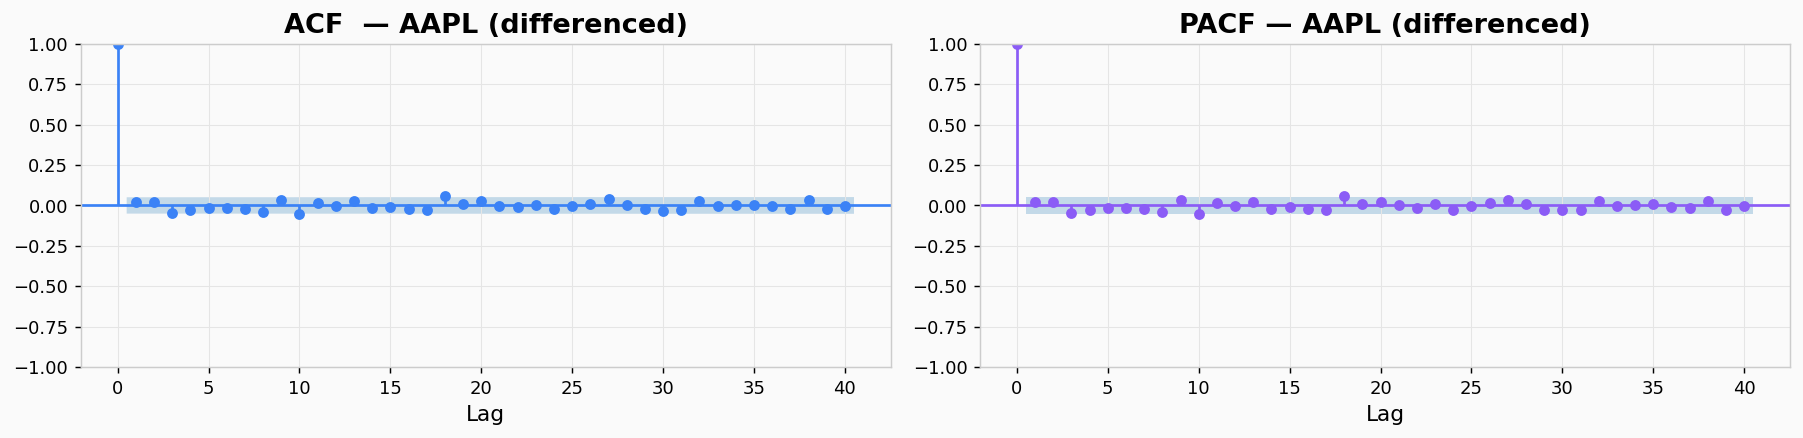

In [7]:
# ── ACF / PACF on differenced AAPL — guides (p, q) selection ──
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

plot_acf(aapl.diff().dropna(), lags=40, ax=axes[0],
         color=PALETTE["train"], vlines_kwargs={"colors": PALETTE["train"]})
axes[0].set_title("ACF  — AAPL (differenced)")
axes[0].set_xlabel("Lag")

plot_pacf(aapl.diff().dropna(), lags=40, ax=axes[1], method="ywm",
          color=PALETTE["accent1"], vlines_kwargs={"colors": PALETTE["accent1"]})
axes[1].set_title("PACF — AAPL (differenced)")
axes[1].set_xlabel("Lag")

for ax in axes:
    ax.set_ylabel("")
fig.tight_layout()
plt.show()

▸ Running ARIMA grid search for AAPL …


/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it ha

  Best order for AAPL: ARIMA(2, 2, 3)  (AIC = 6,176)


/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Predicti

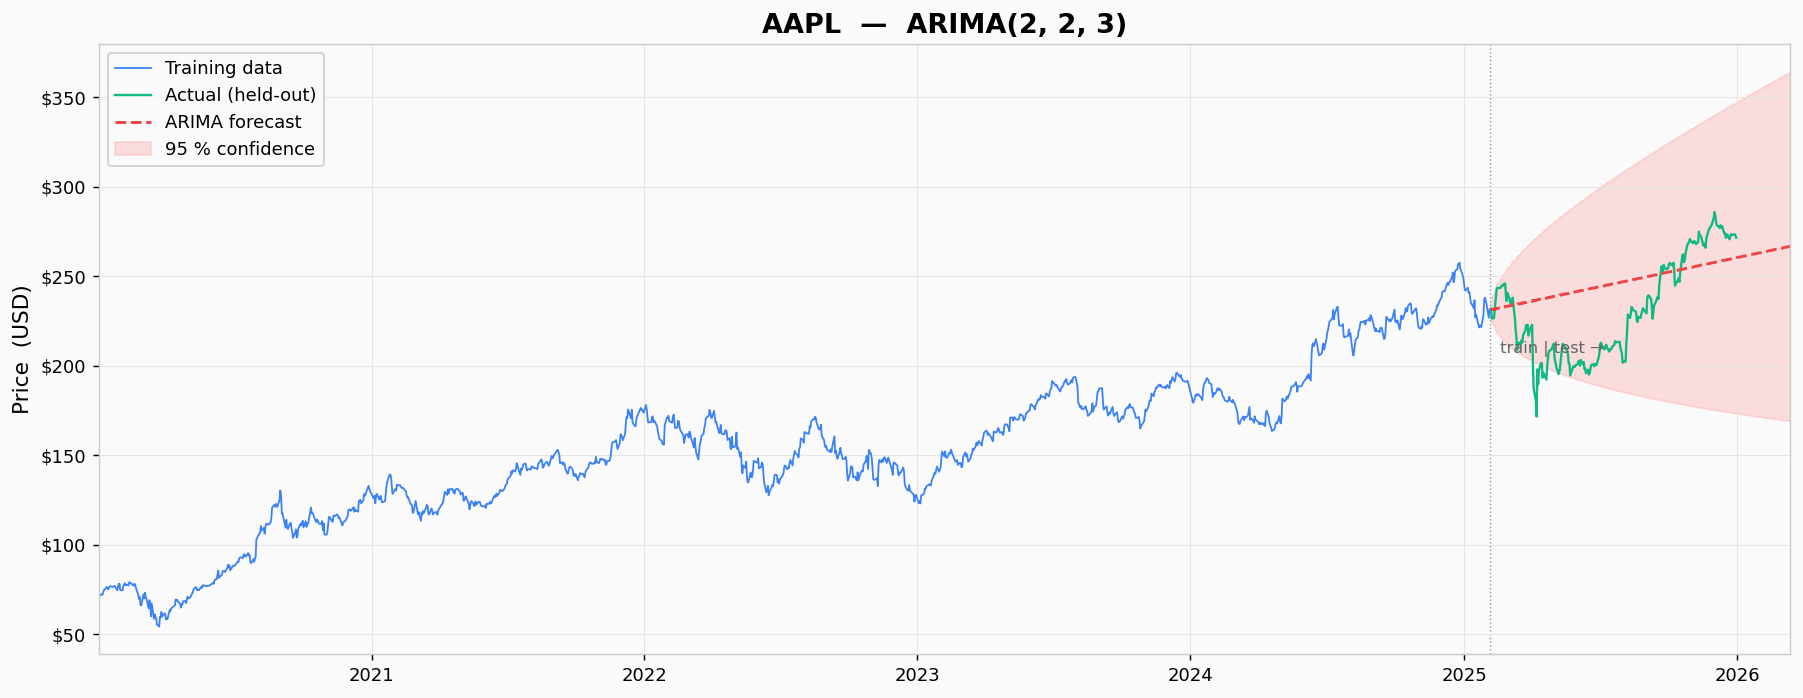

In [8]:
# ── Fit & Forecast AAPL ──
print("▸ Running ARIMA grid search for AAPL …")
res_aapl = run_arima_pipeline(aapl, label="AAPL")
fig_aapl = plot_arima_forecast(res_aapl)

---

## 4 — ARIMA #2 : NVIDIA (NVDA) — The High-Growth Outlier

NVDA has experienced **extreme momentum** driven by AI demand. This stress-tests ARIMA on a series with strong trend and high variance — where the confidence intervals will blow up.

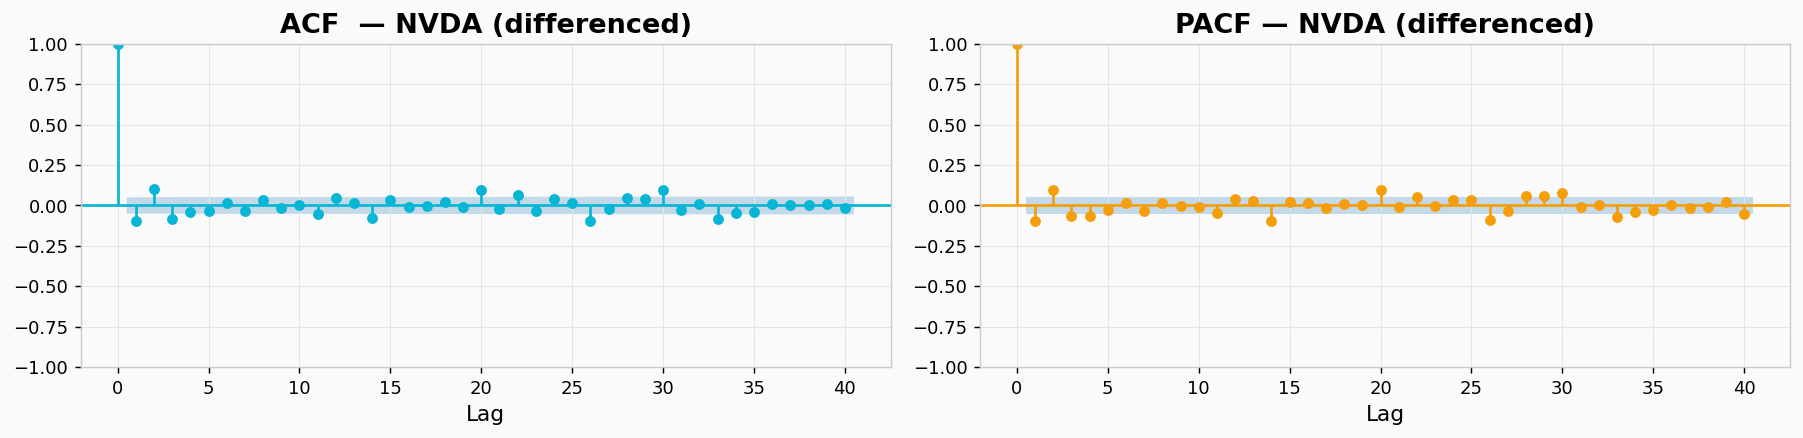

In [9]:
# ── ACF / PACF on differenced NVDA ──
nvda = df_prices["NVDA"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

plot_acf(nvda.diff().dropna(), lags=40, ax=axes[0],
         color=PALETTE["accent3"], vlines_kwargs={"colors": PALETTE["accent3"]})
axes[0].set_title("ACF  — NVDA (differenced)")
axes[0].set_xlabel("Lag")

plot_pacf(nvda.diff().dropna(), lags=40, ax=axes[1], method="ywm",
          color=PALETTE["accent2"], vlines_kwargs={"colors": PALETTE["accent2"]})
axes[1].set_title("PACF — NVDA (differenced)")
axes[1].set_xlabel("Lag")

for ax in axes:
    ax.set_ylabel("")
fig.tight_layout()
plt.show()

▸ Running ARIMA grid search for NVDA …


/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it ha

  Best order for NVDA: ARIMA(3, 1, 3)  (AIC = 5,262)


/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to c

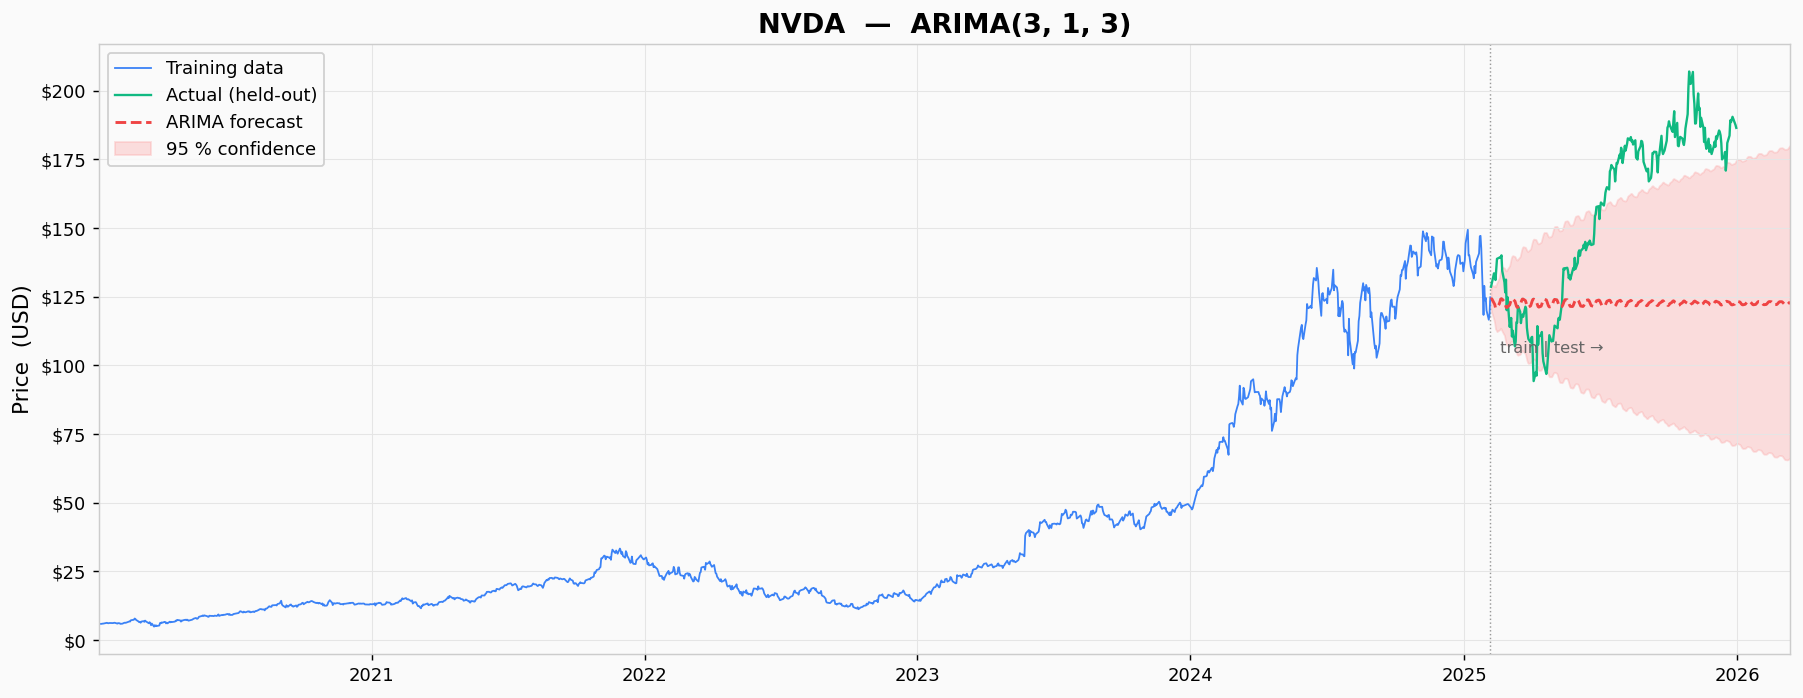

In [10]:
# ── Fit & Forecast NVDA ──
print("▸ Running ARIMA grid search for NVDA …")
res_nvda = run_arima_pipeline(nvda, label="NVDA")
fig_nvda = plot_arima_forecast(res_nvda)

---

## 5 — ARIMA #3 : Equal-Weighted Portfolio — The Diversification Play

An equal-weighted index of all 10 stocks smooths out idiosyncratic noise. ARIMA should produce **tighter confidence bands** here than on any single name, illustrating how **diversification helps forecasting too**.

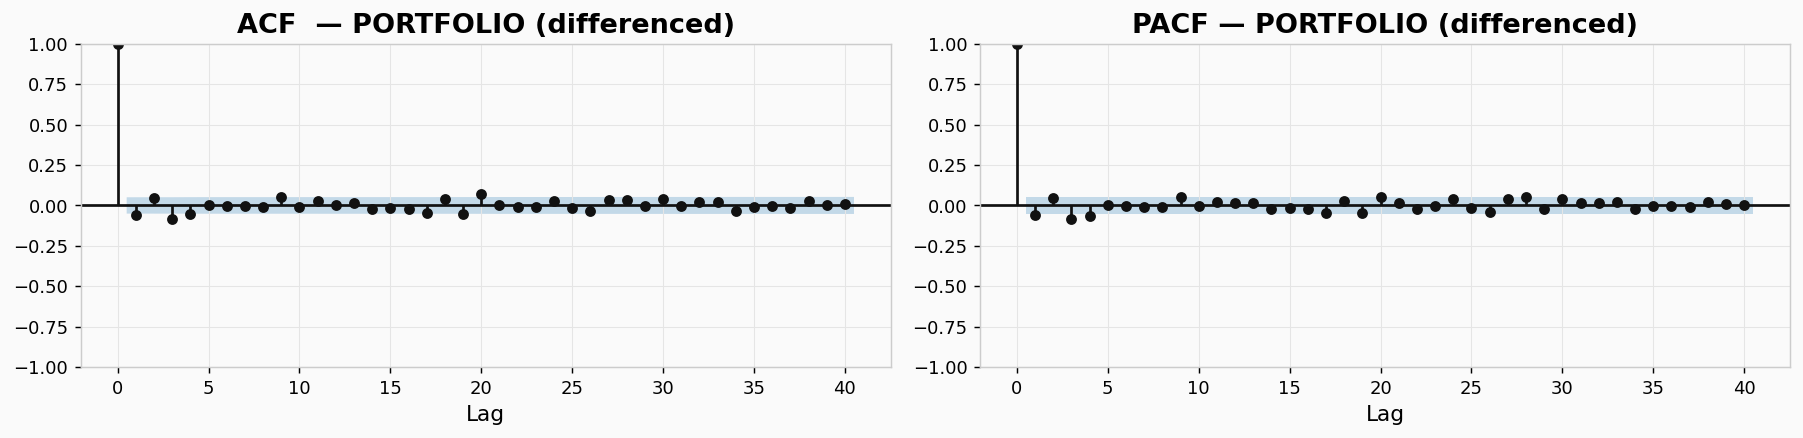

In [11]:
# ── ACF / PACF on differenced PORTFOLIO index ──
port = df_prices["PORTFOLIO"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

plot_acf(port.diff().dropna(), lags=40, ax=axes[0],
         color="#111111", vlines_kwargs={"colors": "#111111"})
axes[0].set_title("ACF  — PORTFOLIO (differenced)")
axes[0].set_xlabel("Lag")

plot_pacf(port.diff().dropna(), lags=40, ax=axes[1], method="ywm",
          color="#111111", vlines_kwargs={"colors": "#111111"})
axes[1].set_title("PACF — PORTFOLIO (differenced)")
axes[1].set_xlabel("Lag")

for ax in axes:
    ax.set_ylabel("")
fig.tight_layout()
plt.show()

▸ Running ARIMA grid search for PORTFOLIO …


/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it ha

  Best order for PORTFOLIO: ARIMA(2, 2, 3)  (AIC = 6,843)


/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/yerik/_apple_lib/_b_envs/0ds_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to c

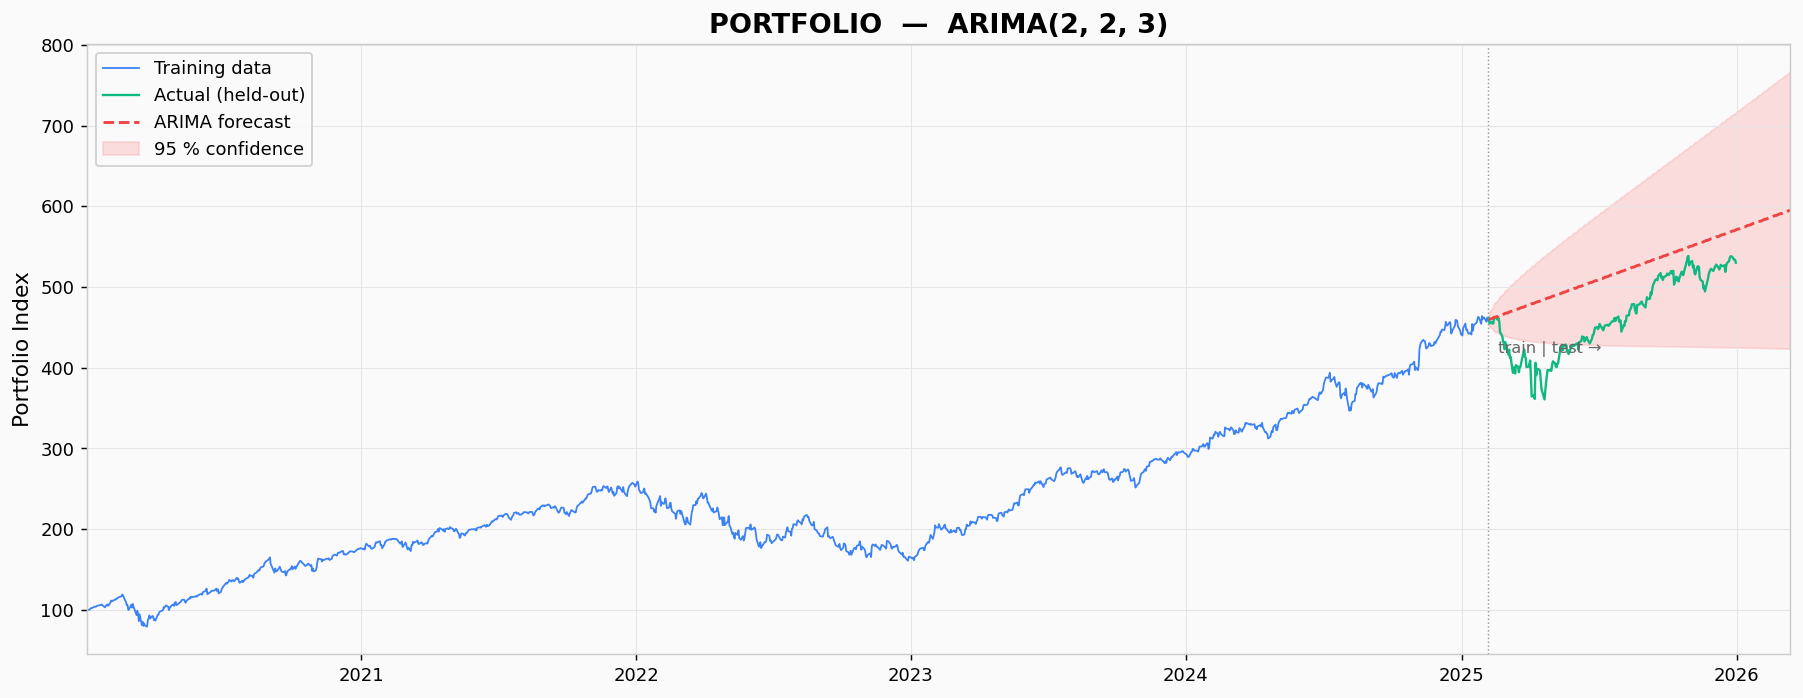

In [12]:
# ── Fit & Forecast PORTFOLIO ──
print("▸ Running ARIMA grid search for PORTFOLIO …")
res_port = run_arima_pipeline(port, label="PORTFOLIO")
fig_port = plot_arima_forecast(res_port)

---

## 6 — Grand Comparison Dashboard

Three forecasts, **one figure** — the cleanest way to compare how ARIMA behaves across different risk profiles.

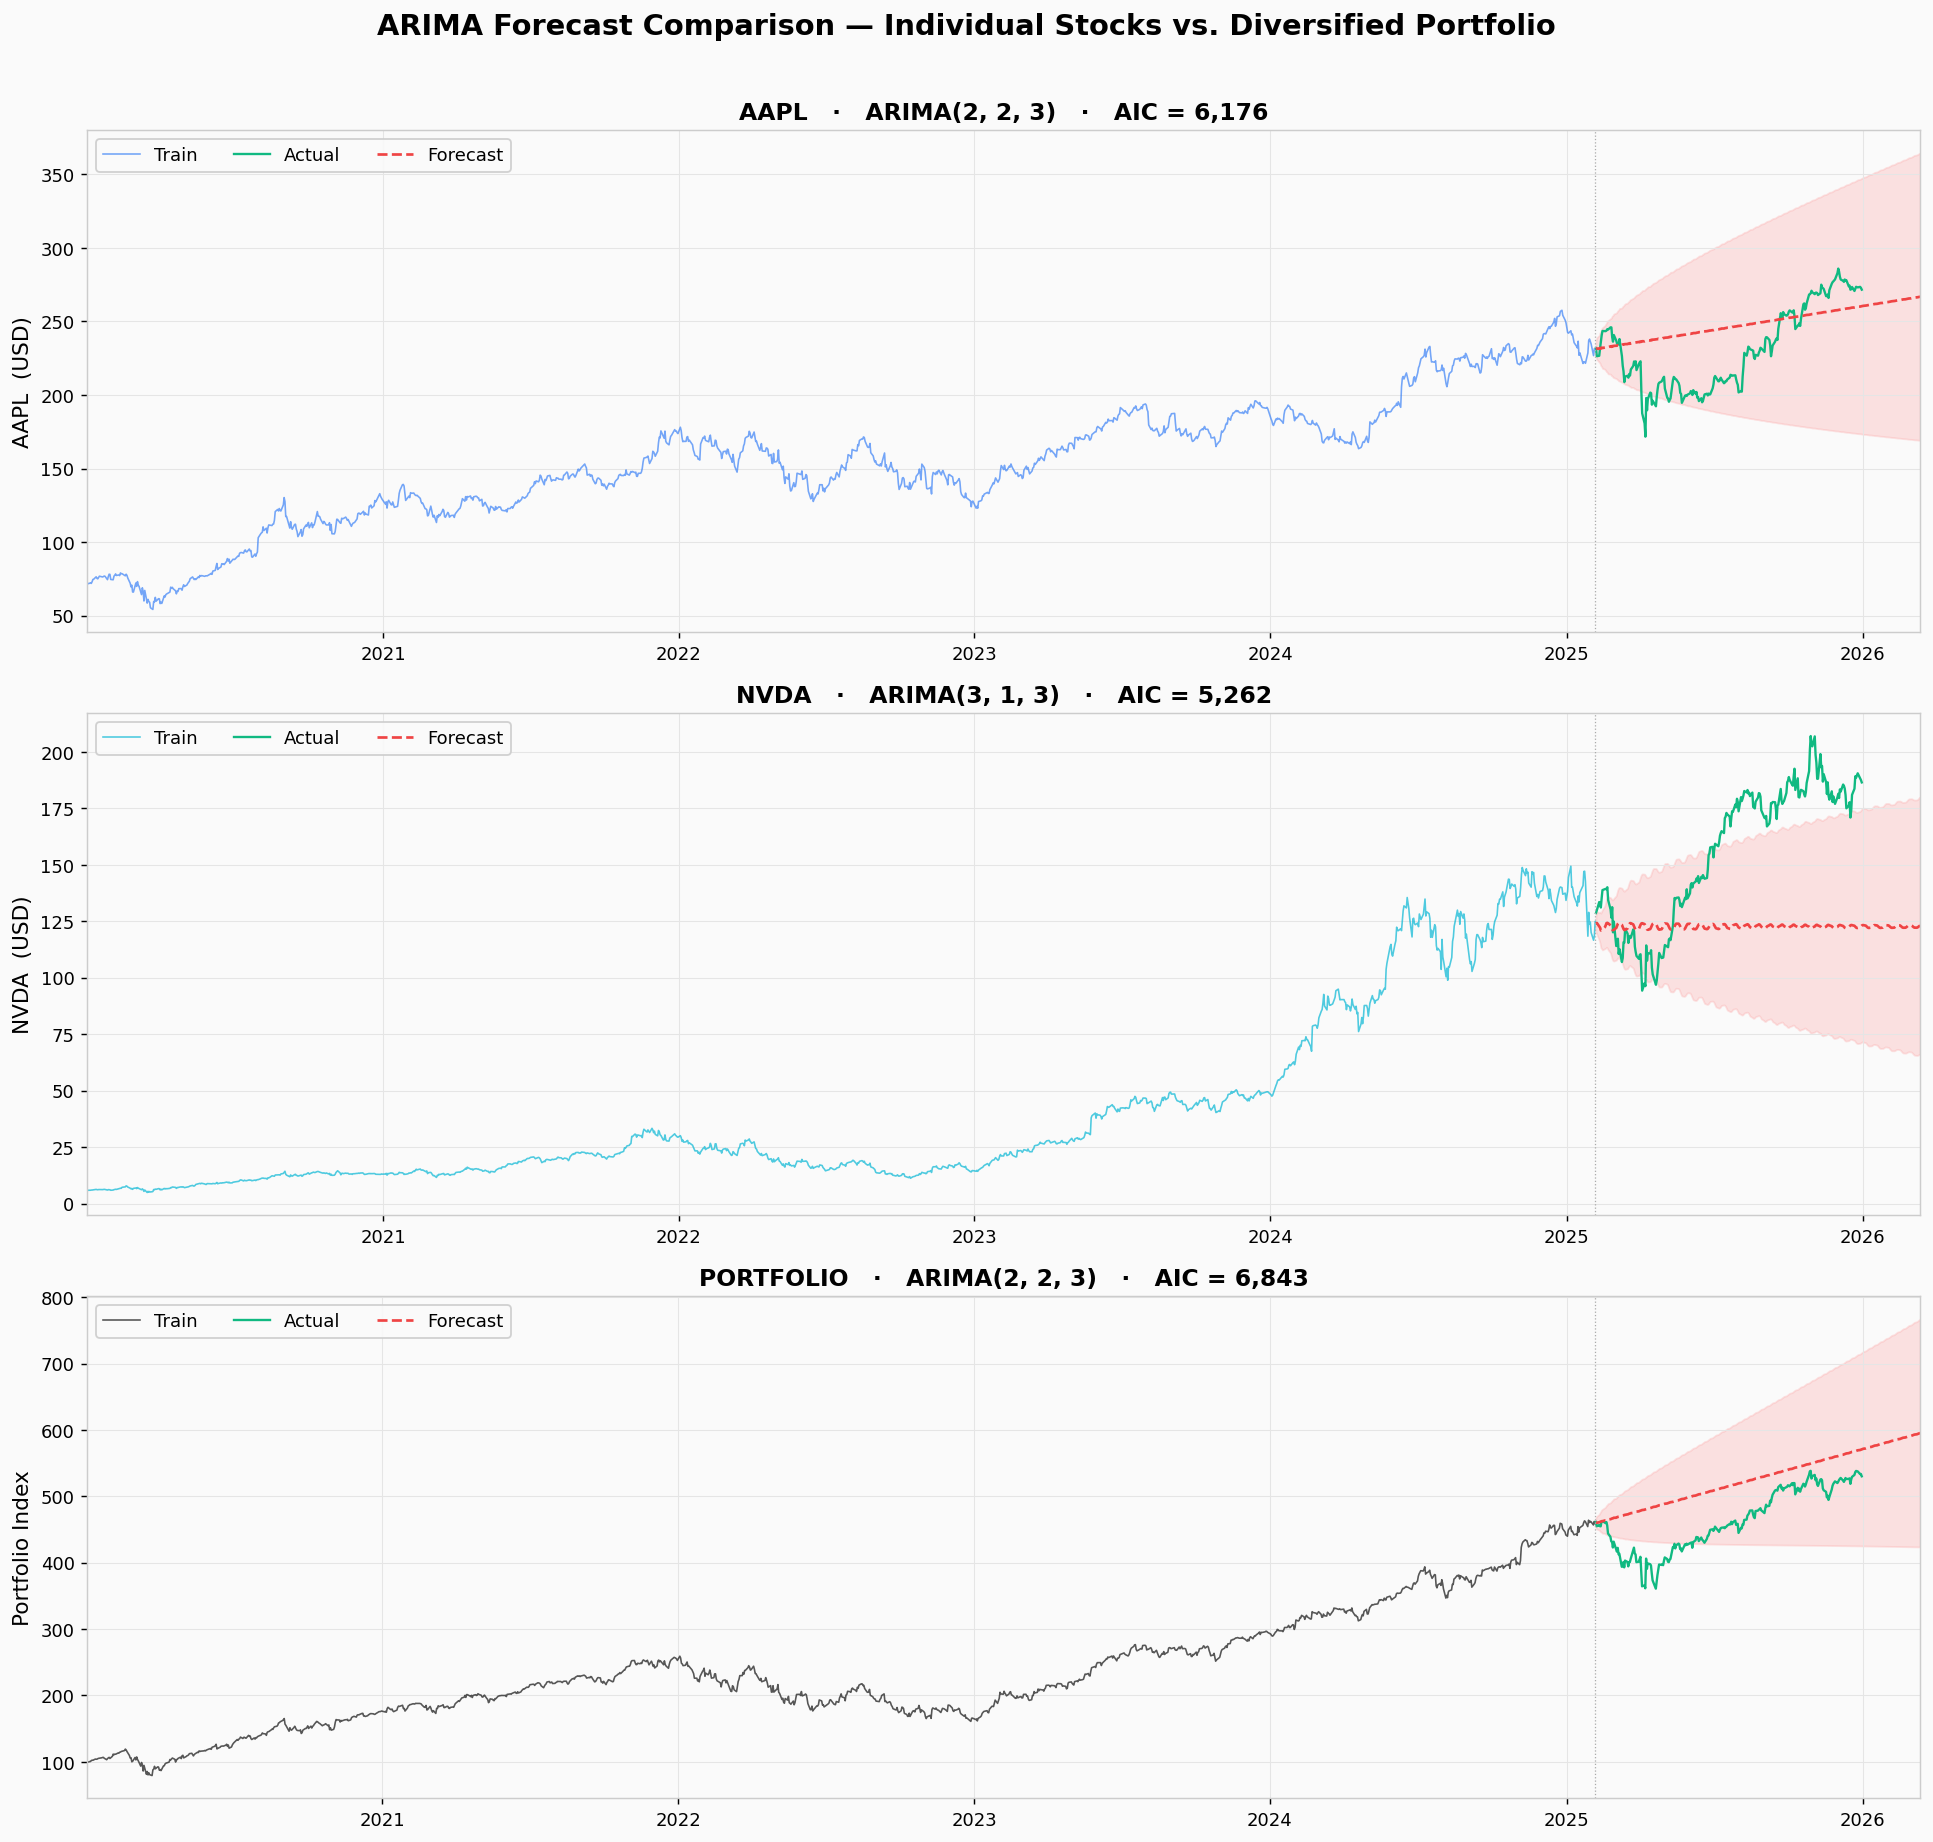

In [13]:
# ── Side-by-side comparison (3 panels) ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=False)

panel_colors = [PALETTE["train"], PALETTE["accent3"], "#111111"]
results_list = [res_aapl, res_nvda, res_port]

for ax, res, clr in zip(axes, results_list, panel_colors):
    # Train
    ax.plot(res["train"].index, res["train"],
            color=clr, linewidth=0.9, alpha=0.7, label="Train")
    # Actual test
    ax.plot(res["test"].index, res["test"],
            color=PALETTE["test"], linewidth=1.3, label="Actual")
    # Forecast
    ax.plot(res["fc_mean"].index, res["fc_mean"],
            color=PALETTE["forecast"], linewidth=1.5, linestyle="--", label="Forecast")
    # Confidence band
    ci = res["fc_ci"]
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],
                    color=PALETTE["ci"], alpha=0.30)
    # Split line
    ax.axvline(res["train"].index[-1], color="#AAAAAA", linewidth=0.7, linestyle=":")
    # Styling
    ax.set_title(f"{res['label']}   ·   ARIMA{res['order']}   ·   AIC = {res['aic']:,.0f}",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", ncol=4)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlim(res["train"].index[0], res["fc_mean"].index[-1])

axes[0].set_ylabel("AAPL  (USD)")
axes[1].set_ylabel("NVDA  (USD)")
axes[2].set_ylabel("Portfolio Index")

fig.suptitle("ARIMA Forecast Comparison — Individual Stocks vs. Diversified Portfolio",
             fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

---

## 7 — Residual Diagnostics

Good residuals should look like **white noise** — no patterns, roughly normal. If they don't, the model is leaving signal on the table.

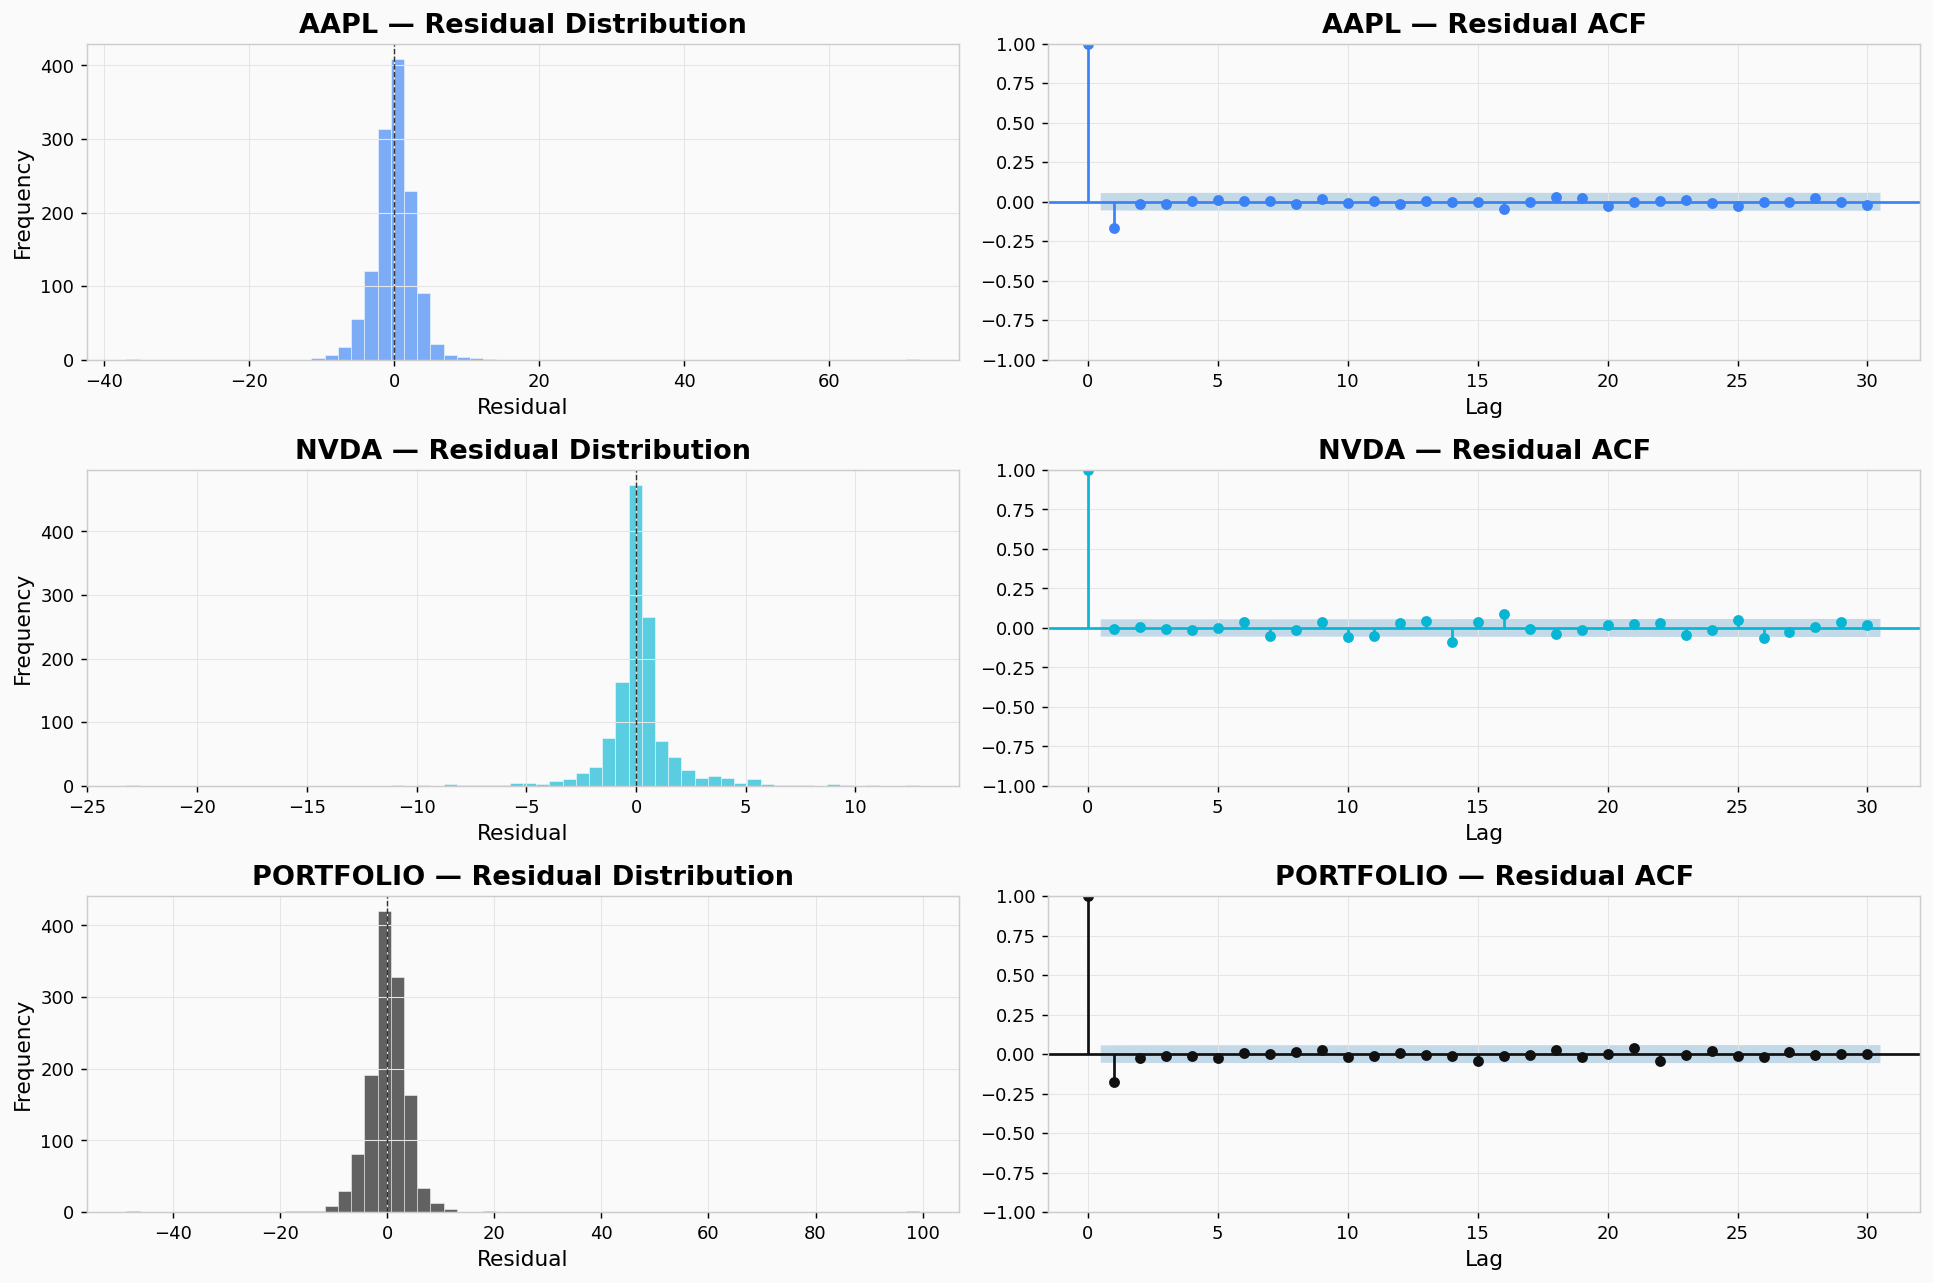

In [14]:
# ── Residual analysis: histogram + Q-Q style ACF for each model ─────
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

labels  = ["AAPL", "NVDA", "PORTFOLIO"]
colors  = [PALETTE["train"], PALETTE["accent3"], "#111111"]
models  = [res_aapl["model"], res_nvda["model"], res_port["model"]]

for row, (mdl, lbl, clr) in enumerate(zip(models, labels, colors)):
    resid = mdl.resid

    # Histogram
    ax_hist = axes[row, 0]
    ax_hist.hist(resid, bins=60, color=clr, alpha=0.65, edgecolor="white", linewidth=0.4)
    ax_hist.axvline(0, color="#333333", linewidth=0.8, linestyle="--")
    ax_hist.set_title(f"{lbl} — Residual Distribution")
    ax_hist.set_xlabel("Residual")
    ax_hist.set_ylabel("Frequency")

    # ACF of residuals
    ax_acf = axes[row, 1]
    plot_acf(resid, lags=30, ax=ax_acf, color=clr,
             vlines_kwargs={"colors": clr})
    ax_acf.set_title(f"{lbl} — Residual ACF")
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("")

fig.tight_layout()
plt.show()

---

## 8 — Forecast Accuracy Metrics

In [15]:
# ── Accuracy table: MAE, RMSE, MAPE on test set ────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

rows = []
for res in results_list:
    test = res["test"]
    fc   = res["fc_mean"].reindex(test.index, method="nearest")
    fc   = fc.iloc[:len(test)]
    mae  = mean_absolute_error(test, fc)
    rmse = np.sqrt(mean_squared_error(test, fc))
    mape = np.mean(np.abs((test.values - fc.values) / test.values)) * 100
    rows.append({
        "Model":      f"{res['label']}  ARIMA{res['order']}",
        "AIC":        f"{res['aic']:,.0f}",
        "MAE":        f"{mae:,.2f}",
        "RMSE":       f"{rmse:,.2f}",
        "MAPE (%)":   f"{mape:.1f}%",
    })

df_metrics = pd.DataFrame(rows)
df_metrics.index = ["" ] * len(df_metrics)
df_metrics.style.set_properties(**{"text-align": "center"})

KeyError: '`Styler.apply` and `.applymap` are not compatible with non-unique index or columns.'

---

## 9 — Confidence-Interval Width: Volatility vs. Forecastability

The chart below plots **how fast the 95% confidence band widens** over the forecast horizon for each model. Tighter = more useful forecast.

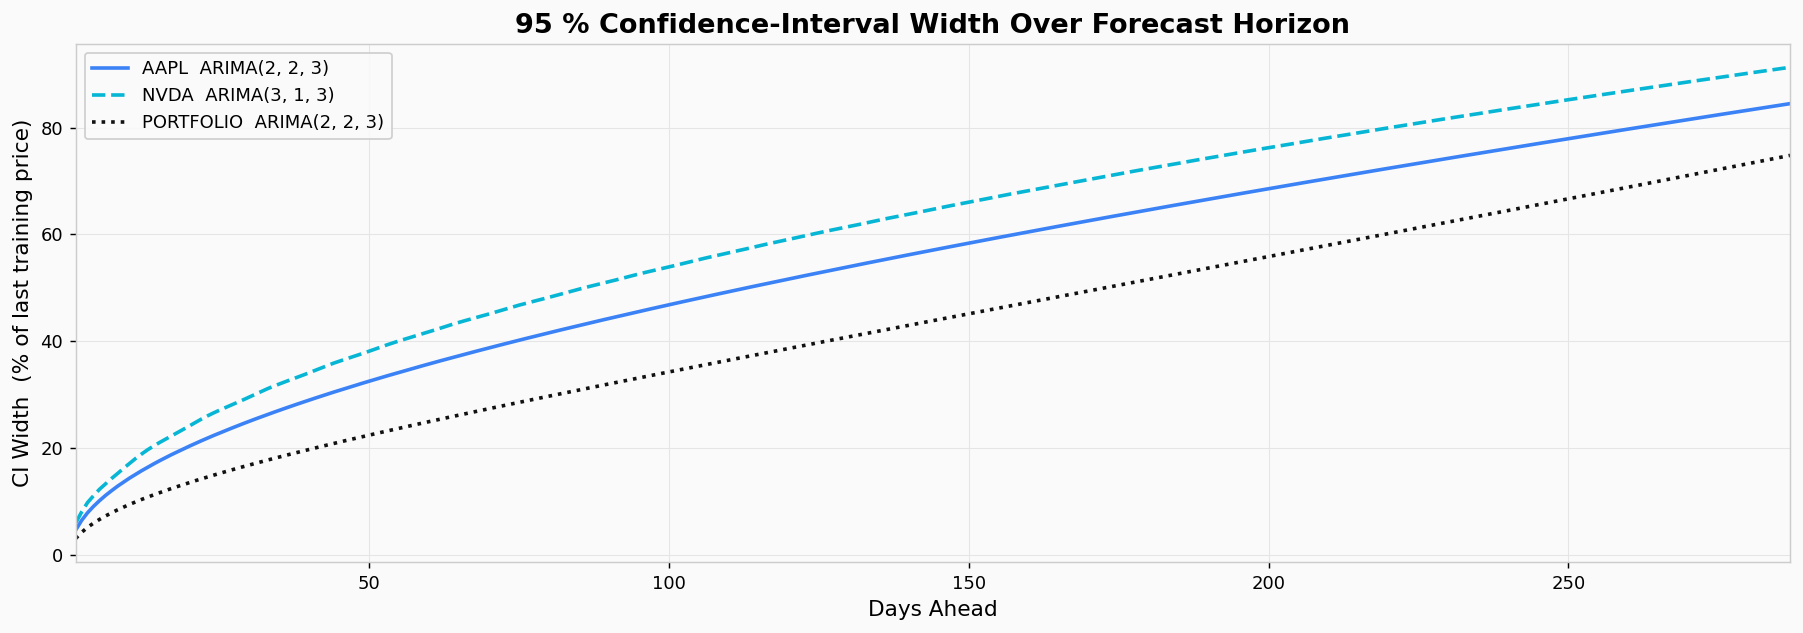

In [16]:
# ── CI width over forecast horizon (normalized to % of last train price) ──
fig, ax = plt.subplots(figsize=(14, 5))

line_styles = ["-", "--", ":"]
colors_ci   = [PALETTE["train"], PALETTE["accent3"], "#111111"]

for res, ls, clr in zip(results_list, line_styles, colors_ci):
    ci = res["fc_ci"]
    width = ci.iloc[:, 1] - ci.iloc[:, 0]
    last_price = res["train"].iloc[-1]
    width_pct  = (width / last_price) * 100
    days = np.arange(1, len(width_pct) + 1)
    ax.plot(days, width_pct.values, linewidth=2, linestyle=ls, color=clr,
            label=f"{res['label']}  ARIMA{res['order']}")

ax.set_title("95 % Confidence-Interval Width Over Forecast Horizon")
ax.set_xlabel("Days Ahead")
ax.set_ylabel("CI Width  (% of last training price)")
ax.legend(frameon=True)
ax.set_xlim(1, len(days))
fig.tight_layout()
plt.show()

---

## 10 — Zoomed-In: Test Period Only

Sometimes you want to **really** see how well the forecast tracked reality. These zoomed panels show only the held-out test window alongside the ARIMA prediction.

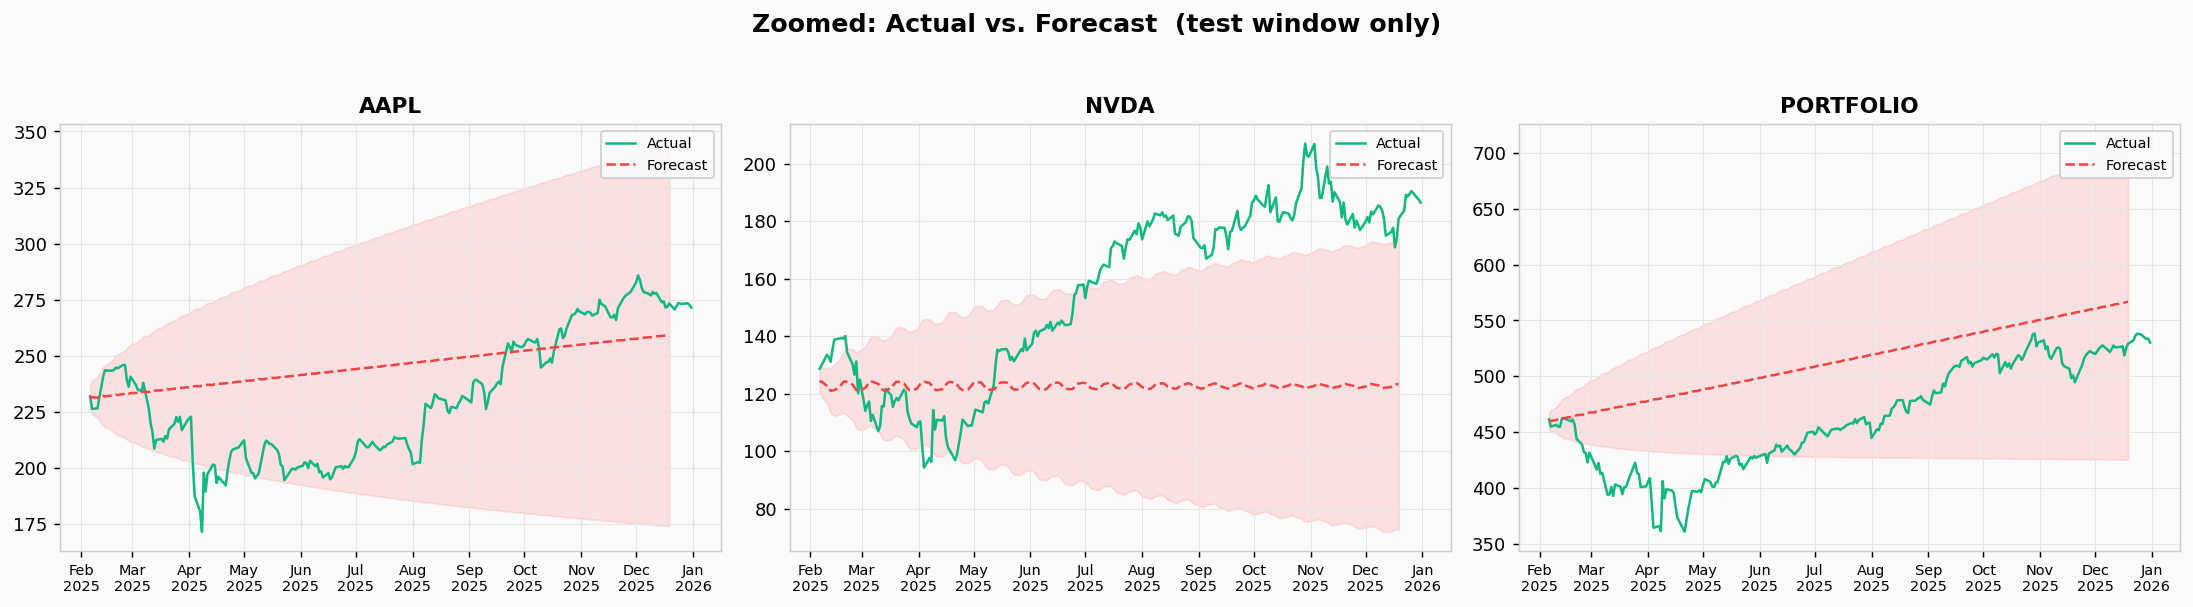

In [17]:
# ── Zoomed test-window panels ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, res, clr in zip(axes, results_list, colors_ci):
    test = res["test"]
    fc_test = res["fc_mean"].iloc[:len(test)]

    ax.plot(test.index, test.values, color=PALETTE["test"],
            linewidth=1.4, label="Actual")
    ax.plot(fc_test.index, fc_test.values, color=PALETTE["forecast"],
            linewidth=1.4, linestyle="--", label="Forecast")

    ci = res["fc_ci"].iloc[:len(test)]
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],
                    color=PALETTE["ci"], alpha=0.3)

    ax.set_title(f"{res['label']}", fontsize=12, fontweight="bold")
    ax.legend(loc="best", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Zoomed: Actual vs. Forecast  (test window only)",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

---

## Key Takeaways

| Insight | Detail |
|---------|--------|
| **ARIMA works best on stable, mean-reverting series** | AAPL's forecast stays closer to actuals than NVDA's explosive trend. |
| **Volatility kills confidence** | NVDA's CI band blows up quickly — ARIMA can't capture regime changes from AI hype cycles. |
| **Diversification tightens forecasts** | The equal-weighted portfolio has smoother dynamics, giving ARIMA more to work with. |
| **Residual diagnostics matter** | If residuals show autocorrelation, the model is under-specified — consider SARIMAX, GARCH, or ML approaches. |
| **ARIMA is a baseline, not a crystal ball** | It captures linear structure in the data; pair it with fundamental analysis and volatility models for real trading. |

---
*Notebook generated for educational purposes — not financial advice.*